ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

![step1.png](attachment:step1.png)

In [52]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [53]:
# Load Dataset
df = pd.read_csv("airbnb_top_cities.csv")
# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head()

/tmp/ipykernel_1981/694320028.py:2: DtypeWarning: Columns (4,17) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("airbnb_top_cities.csv")


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,city,scrape_date
0,13913,Holiday London DB Room Let-on going,54730,Alina,NaN,Islington,51.56861,-0.11270,Private room,70.0,1,55,2025-08-21,0.30,2,331,10,NaN,London,2026-03-29
1,15400,Bright Chelsea Apartment. Chelsea!,60302,Philippa,NaN,Kensington and Chelsea,51.48780,-0.16813,Entire home/apt,149.0,4,97,2025-04-05,0.51,1,199,1,NaN,London,2026-03-29
2,17402,Very Central Modern 3-Bed/2 Bath By Oxford St W1,67564,Liz,NaN,Westminster,51.52195,-0.14094,Entire home/apt,411.0,3,56,2024-02-19,0.32,2,80,0,NaN,London,2026-03-29
3,24328,Battersea live/work artist house,41759,Joe,NaN,Wandsworth,51.47072,-0.16266,Entire home/apt,NaN,7,95,2025-07-05,0.53,1,294,1,NaN,London,2026-03-29
4,36274,Bright 1 bedroom apt off brick lane in Shoreditch,133271,Hendryks,NaN,Tower Hamlets,51.52322,-0.06979,Entire home/apt,210.0,5,15,2025-09-06,0.09,2,323,6,NaN,London,2026-03-29


### Check Missing Values

In [54]:
# Check missing values
print(df.isnull())

           id   name  host_id  host_name  neighbourhood_group  neighbourhood  \
0       False  False    False      False                 True          False   
1       False  False    False      False                 True          False   
2       False  False    False      False                 True          False   
3       False  False    False      False                 True          False   
4       False  False    False      False                 True          False   
...       ...    ...      ...        ...                  ...            ...   
292797  False  False    False      False                 True          False   
292798  False  False    False      False                 True          False   
292799  False  False    False      False                 True          False   
292800  False  False    False      False                 True          False   
292801  False  False    False      False                 True          False   

        latitude  longitude  room_type 

In [55]:
print(df.isnull().sum())

id                                     0
name                                   0
host_id                                0
host_name                             90
neighbourhood_group               273392
neighbourhood                          0
latitude                               0
longitude                              0
room_type                              0
price                             152852
minimum_nights                         0
number_of_reviews                      0
last_review                        66365
reviews_per_month                  66365
calculated_host_listings_count         0
availability_365                       0
number_of_reviews_ltm                  0
license                           152949
city                                   0
scrape_date                            0
dtype: int64


### Check duplicate rows

In [56]:
# checking duplicate rows
print(df.duplicated().sum())

0


### No. of rows and columns

In [57]:
# finding number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (292802, 20) 

number of rows:  292802
number of columns:  20


### Data type of columns

In [58]:
# viewing the data types of columns
df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,float64


In [59]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['minimum_nights'] = pd.to_numeric(df['minimum_nights'], errors='coerce')
df['number_of_reviews'] = pd.to_numeric(df['number_of_reviews'], errors='coerce')
df['reviews_per_month'] = pd.to_numeric(df['reviews_per_month'], errors='coerce')
df['availability_365'] = pd.to_numeric(df['availability_365'], errors='coerce')

df.dtypes

,0
id,int64
name,object
host_id,int64
host_name,object
neighbourhood_group,object
neighbourhood,object
latitude,float64
longitude,float64
room_type,object
price,float64


In [60]:
# Statistical summary
df.describe(include='all')

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,city,scrape_date
count,2.928020e+05,292802,2.928020e+05,292712,19410,292802,292802.000000,292802.000000,292802,1.399500e+05,292802.000000,292802.000000,226437,226437.000000,292802.000000,292802.000000,292802.000000,139853,292802,292802
unique,NaN,278076,NaN,38242,10,248,NaN,NaN,4,NaN,NaN,NaN,3976,NaN,NaN,NaN,NaN,107008,7,1
top,NaN,Appartement,NaN,David,Eixample,I Centro Storico,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2025-08-31,NaN,NaN,NaN,NaN,Exempt,London,2026-03-29
freq,NaN,85,NaN,1548,6906,18563,NaN,NaN,216782,NaN,NaN,NaN,4987,NaN,NaN,NaN,NaN,8616,96871,292802
mean,6.925516e+17,NaN,2.169006e+08,NaN,NaN,NaN,40.009043,21.583817,NaN,6.042208e+02,18.515328,31.822187,NaN,1.169245,21.022343,162.651423,7.942511,NaN,NaN,NaN
std,5.785082e+17,NaN,2.219687e+08,NaN,NaN,NaN,21.677901,43.996214,NaN,7.403676e+03,65.016518,73.409545,NaN,1.535733,69.392336,139.492379,15.926128,NaN,NaN,NaN
min,2.737000e+03,NaN,1.662000e+03,NaN,NaN,NaN,-34.095680,-0.496760,NaN,4.000000e+00,1.000000,0.000000,NaN,0.010000,1.000000,0.000000,0.000000,NaN,NaN,NaN
25%,3.347211e+07,NaN,2.495756e+07,NaN,NaN,NaN,41.878008,-0.066950,NaN,9.400000e+01,1.000000,1.000000,NaN,0.200000,1.000000,0.000000,0.000000,NaN,NaN,NaN
50%,8.724348e+17,NaN,1.180033e+08,NaN,NaN,NaN,48.866320,2.335690,NaN,1.630000e+02,2.000000,7.000000,NaN,0.630000,2.000000,155.000000,1.000000,NaN,NaN,NaN
75%,1.208697e+18,NaN,4.221622e+08,NaN,NaN,NaN,51.495854,12.463966,NaN,3.420000e+02,5.000000,29.000000,NaN,1.610000,9.000000,304.000000,9.000000,NaN,NaN,NaN


### Descriptive summary Statistics

### Univariate Analysis

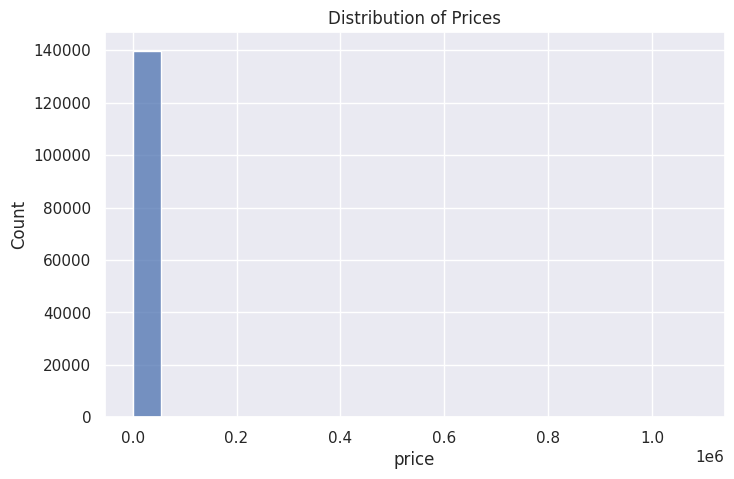

In [61]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=20)
plt.title("Distribution of Prices")
plt.show()

- Shows how shipment sizes are distributed
- Right skew = many small shipments, few large ones

### Distribution of Minimum Nights

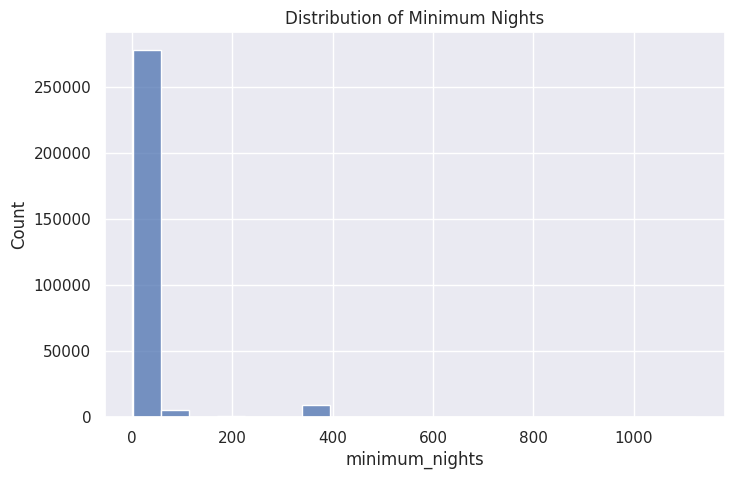

In [62]:
plt.figure(figsize=(8,5))
sns.histplot(df['minimum_nights'], bins=20)
plt.title("Distribution of Minimum Nights")
plt.show()

## Bivariate Analysis

### Price by Neighbourhood Group

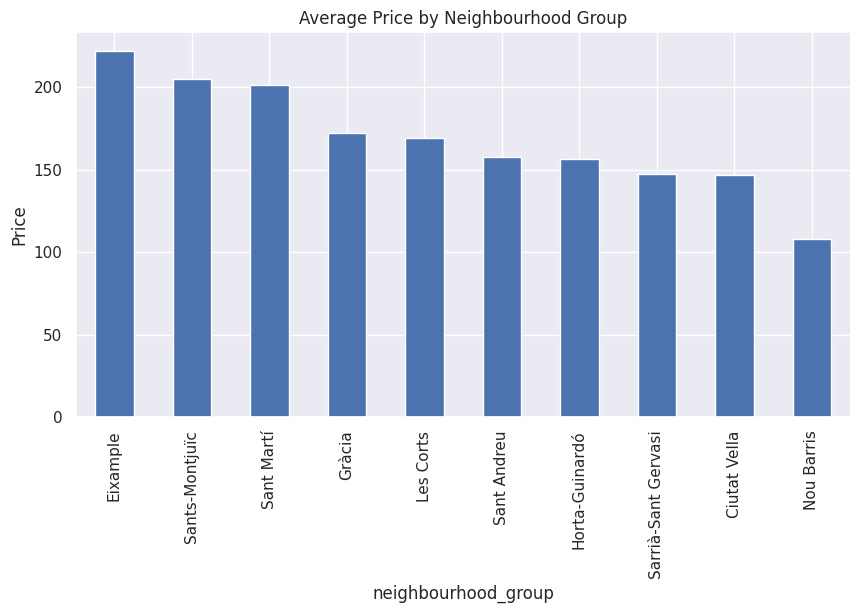

,price
neighbourhood_group,
Eixample,222.190991
Sants-Montjuïc,205.202937
Sant Martí,201.022949
Gràcia,171.976314
Les Corts,169.437888
Sant Andreu,157.508772
Horta-Guinardó,156.397561
Sarrià-Sant Gervasi,147.131833
Ciutat Vella,147.058568


In [63]:
neighbourhood_price = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
neighbourhood_price.plot(kind='bar')
plt.title("Average Price by Neighbourhood Group")
plt.ylabel("Price")
plt.show()

neighbourhood_price

### Price by Room Types

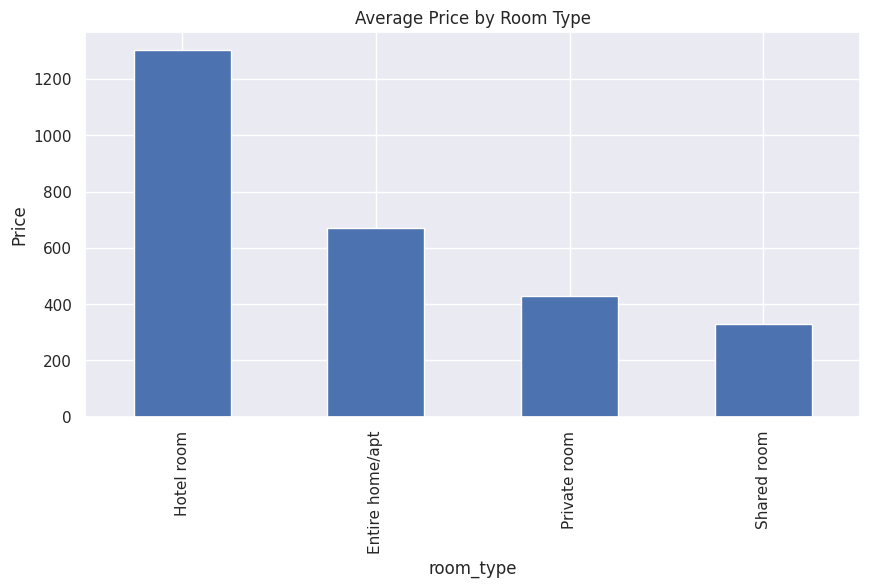

,price
room_type,
Hotel room,1302.388988
Entire home/apt,670.121407
Private room,429.524092
Shared room,327.671766


In [64]:
price_by_room = df.groupby('room_type')['price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
price_by_room.plot(kind='bar')
plt.title("Average Price by Room Type")
plt.ylabel("Price")
plt.show()

price_by_room

### Price by Host

In [65]:
price_by_host = df.groupby('host_name')['price'].mean().sort_values(ascending=False)

price_by_host.head(10)

,price
host_name,
พรชัย,928572.000000
Yasmine,666719.666667
John Carlo,321829.000000
Wanlapatch,152000.000000
Nichkhun,102858.000000
Lady,100000.000000
วิทยาธร,100000.000000
Naamtran,80000.000000
Khajorn,70886.000000


### Price vs Number of Reviews

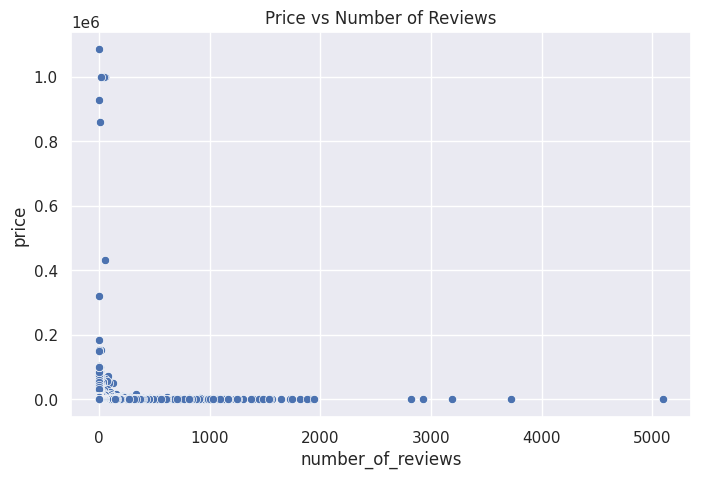

In [66]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='number_of_reviews', y='price', data=df)
plt.title("Price vs Number of Reviews")
plt.show()

### Correlation Matrix

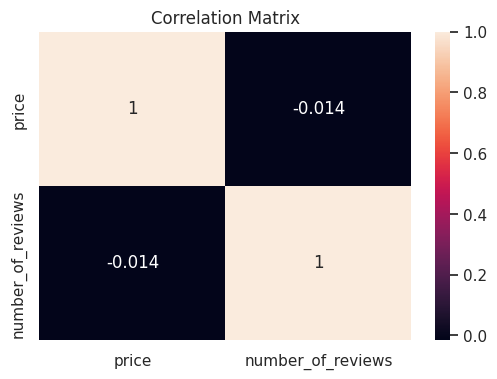

In [67]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['price', 'number_of_reviews']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

## Time-Based Analysis
### Monthly Price Trend

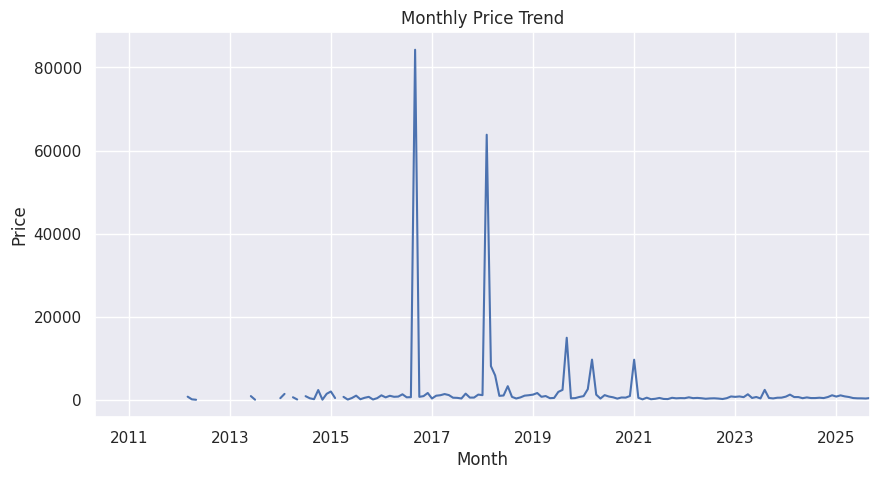

In [68]:
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')

df['Month'] = df['last_review'].dt.to_period('M')

monthly_price = df.groupby('Month')['price'].mean()

plt.figure(figsize=(10,5))
monthly_price.plot()
plt.title("Monthly Price Trend")
plt.ylabel("Price")
plt.show()

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
